# Split Integrity & Data Leakage Diagnostic

**Purpose:** Before recomputing any classification metrics, verify that the train/test split used across all models is sound. This notebook checks three things, none of which require model checkpoints or retraining:

1. **ImageFolder ordering** — whether the two separate `ImageFolder` objects (`train_dataset_aug` and `test_dataset_clean`) enumerate files in *identical* order. If they don't, images and labels silently mismatch and every reported metric is invalid.
2. **Cross-split duplication** — whether any training image is a pixel-level or near-duplicate of a test image (perceptual hashing). This is the classic leak in public DR datasets that inflates accuracy.
3. **Class distribution** — how many images of each class land in train vs test, so we can see whether `Severe` is simply starved of test examples.

Run every cell top to bottom. At the end you'll get a plain-language verdict. Paste that verdict back and we decide the next step together.

In [1]:
# ============================================================
# CONFIG — change ONLY this cell if your paths differ
# ============================================================

# The dataset root that your training notebooks used.
# (Your CNN notebook used the first path; the transformer notebook used the second.
#  Set this to whichever is correct in your CURRENT Kaggle session.)
DATA_ROOT = "/kaggle/input/datasets/shajinrp/diabetic-retinopathy/Dataset"

# The split settings your notebooks used — do NOT change these,
# they must match training exactly to reproduce the same split.
TRAIN_RATIO = 0.8
SPLIT_SEED  = 42

# Perceptual-hash sensitivity. Hamming distance <= this counts as a near-duplicate.
# 0 = pixel-identical only. 5 = catches mild recompression/resize/crop duplicates.
PHASH_THRESHOLD = 5

import os
assert os.path.isdir(DATA_ROOT), f"DATA_ROOT does not exist: {DATA_ROOT}\nList /kaggle/input to find the right path."
print("Dataset root OK:", DATA_ROOT)

Dataset root OK: /kaggle/input/datasets/shajinrp/diabetic-retinopathy/Dataset


In [2]:
!pip install ImageHash --quiet

import torch
import numpy as np
from torchvision import datasets
from collections import Counter, defaultdict

print("torch:", torch.__version__)

torch: 2.10.0+cu128


## Check 1 — Do the two ImageFolder objects enumerate files identically?

Your training code built `train_dataset_aug` and `test_dataset_clean` as **two separate `ImageFolder` calls** on the same root, then indexed both with the same `train_indices` / `test_indices`. That is only valid if both objects list their files in exactly the same order. We reconstruct both and compare their `.samples` lists element by element.

In [3]:
# Build two independent ImageFolder objects, exactly like the training notebooks did.
folder_a = datasets.ImageFolder(root=DATA_ROOT)  # stood in for train_dataset_aug
folder_b = datasets.ImageFolder(root=DATA_ROOT)  # stood in for test_dataset_clean

paths_a = [p for p, _ in folder_a.samples]
paths_b = [p for p, _ in folder_b.samples]

class_names = folder_a.classes
print("Classes (index order):", class_names)
print("Total images:", len(paths_a))

ordering_identical = (paths_a == paths_b)
print("\nImageFolder ordering identical between the two objects:", ordering_identical)

if not ordering_identical:
    # Show the first few mismatches so we can see how bad it is
    mismatches = [(i, a, b) for i, (a, b) in enumerate(zip(paths_a, paths_b)) if a != b]
    print(f"  Number of positions where ordering differs: {len(mismatches)}")
    for i, a, b in mismatches[:5]:
        print(f"   idx {i}: A={os.path.basename(a)}  B={os.path.basename(b)}")

Classes (index order): ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']
Total images: 3554

ImageFolder ordering identical between the two objects: True


## Reconstruct the exact train/test split

This mirrors the transformer notebook's split logic (`torch.randperm` with `manual_seed(42)`, 80/20). This is the split most of your models used. We save the resulting index lists to disk so later notebooks can reuse the *identical* split.

In [4]:
total_len  = len(folder_a)
train_size = int(total_len * TRAIN_RATIO)

generator     = torch.Generator().manual_seed(SPLIT_SEED)
indices       = torch.randperm(total_len, generator=generator).tolist()
train_indices = indices[:train_size]
test_indices  = indices[train_size:]

labels_all  = [lbl for _, lbl in folder_a.samples]
train_lbls  = [labels_all[i] for i in train_indices]
test_lbls   = [labels_all[i] for i in test_indices]

print(f"Train: {len(train_indices)}   Test: {len(test_indices)}")

# Save for reuse by downstream notebooks (identical split guaranteed)
np.save("/kaggle/working/train_indices.npy", np.array(train_indices))
np.save("/kaggle/working/test_indices.npy",  np.array(test_indices))
print("Saved train_indices.npy and test_indices.npy to /kaggle/working/")

Train: 2843   Test: 711
Saved train_indices.npy and test_indices.npy to /kaggle/working/


## Check 2 — Class distribution across the split

If `Severe` has very few test images, per-class recall on it will be noisy regardless of leakage. This tells us how much weight to put on the Severe numbers.

In [5]:
train_counts = Counter(train_lbls)
test_counts  = Counter(test_lbls)

print(f"{'Class':<18}{'Train':>8}{'Test':>8}{'Test %':>9}")
print('-' * 43)
for i, cls in enumerate(class_names):
    tr, te = train_counts.get(i, 0), test_counts.get(i, 0)
    tot = tr + te
    pct = (100 * te / tot) if tot else 0
    print(f"{cls:<18}{tr:>8}{te:>8}{pct:>8.1f}%")

Class                Train    Test   Test %
-------------------------------------------
Mild                   428      99    18.8%
Moderate               319      76    19.2%
No_DR                  778     190    19.6%
Proliferate_DR         863     226    20.8%
Severe                 455     120    20.9%


## Check 3 — Cross-split near-duplicate detection (the main leak test)

We compute a perceptual hash (pHash) for every image, then check how many **test** images have a near-duplicate (Hamming distance ≤ `PHASH_THRESHOLD`) somewhere in the **train** set. Any such image is effectively leaked: the model may have seen a near-identical copy during training.

This reads every image once. On a few thousand images it takes a couple of minutes.

In [6]:
import imagehash
from PIL import Image

def compute_phash(path):
    try:
        with Image.open(path) as im:
            return imagehash.phash(im.convert("RGB"))
    except Exception as e:
        print("  could not hash", os.path.basename(path), "-", e)
        return None

print("Hashing all images (this is the slow cell)...")
all_hashes = [compute_phash(p) for p in paths_a]
print("Done. Hashed", sum(h is not None for h in all_hashes), "images.")

Hashing all images (this is the slow cell)...
Done. Hashed 3554 images.


In [7]:
# Bucket train hashes for fast lookup. For threshold-based matching we compare
# each test hash against all train hashes; with a few thousand images this is fine.

train_hashes = [(i, all_hashes[i]) for i in train_indices if all_hashes[i] is not None]

# Exact-duplicate fast path via string buckets
train_hash_map = defaultdict(list)
for i, h in train_hashes:
    train_hash_map[str(h)].append(i)

leaked = []          # (test_idx, train_idx, distance)
exact_leaks = 0
near_leaks  = 0

for ti in test_indices:
    th = all_hashes[ti]
    if th is None:
        continue
    # exact match first
    if str(th) in train_hash_map:
        leaked.append((ti, train_hash_map[str(th)][0], 0))
        exact_leaks += 1
        continue
    # near match (only if threshold > 0)
    if PHASH_THRESHOLD > 0:
        best_i, best_d = None, 999
        for tri, trh in train_hashes:
            d = th - trh
            if d < best_d:
                best_d, best_i = d, tri
                if best_d == 1:
                    break
        if best_d <= PHASH_THRESHOLD:
            leaked.append((ti, best_i, best_d))
            near_leaks += 1

n_test = sum(all_hashes[i] is not None for i in test_indices)
print(f"Test images checked      : {n_test}")
print(f"Exact duplicates in train: {exact_leaks}")
print(f"Near duplicates in train : {near_leaks}  (Hamming <= {PHASH_THRESHOLD})")
print(f"Total leaked test images : {len(leaked)}  ({100*len(leaked)/max(n_test,1):.1f}% of test set)")

Test images checked      : 711
Exact duplicates in train: 46
Near duplicates in train : 171  (Hamming <= 5)
Total leaked test images : 217  (30.5% of test set)


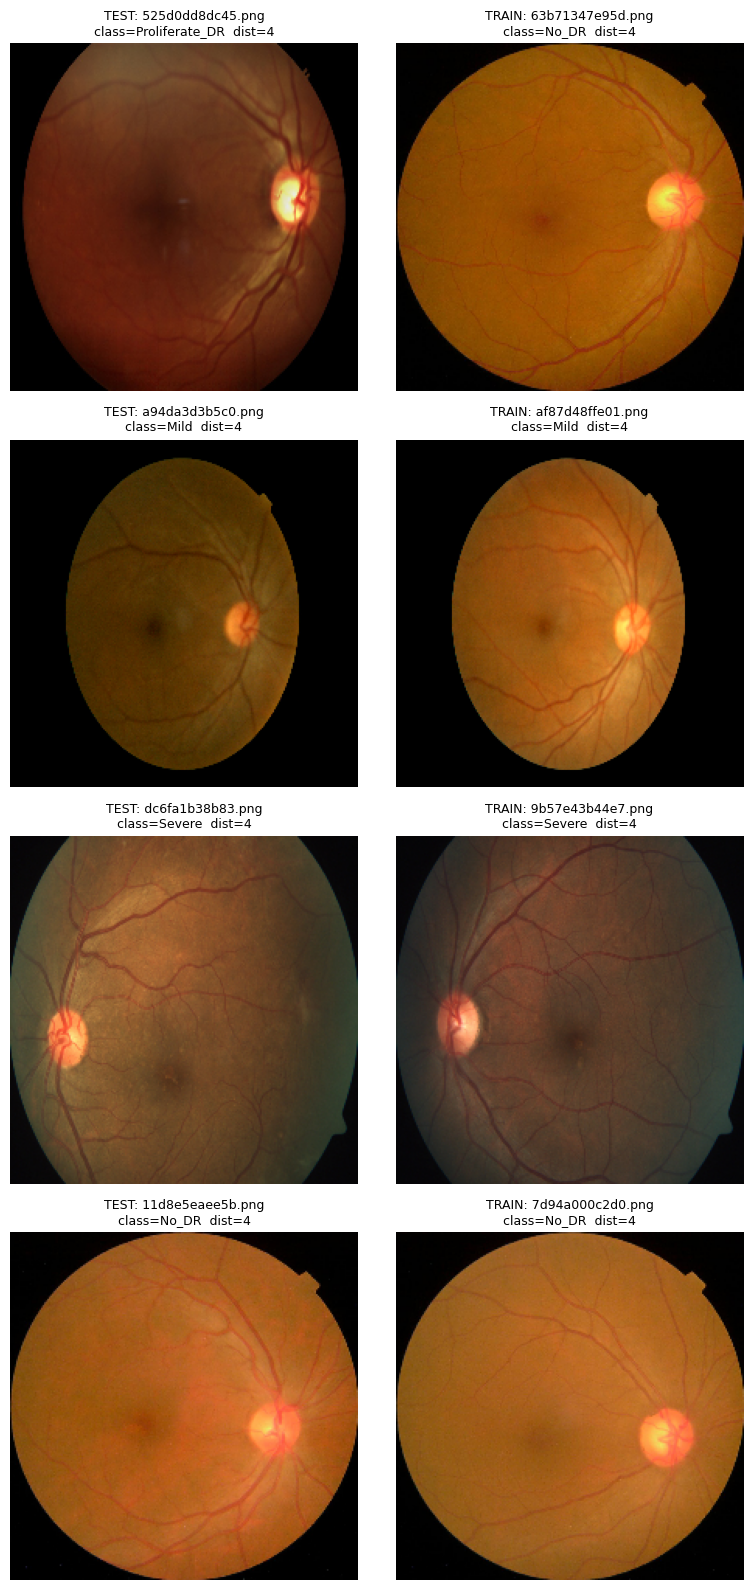

In [8]:
# Show a few leaked pairs so you can eyeball them
import matplotlib.pyplot as plt

if leaked:
    n_show = min(4, len(leaked))
    fig, axes = plt.subplots(n_show, 2, figsize=(8, 4 * n_show))
    if n_show == 1:
        axes = axes.reshape(1, 2)
    for row, (ti, tri, d) in enumerate(leaked[:n_show]):
        for col, (idx, tag) in enumerate([(ti, "TEST"), (tri, "TRAIN")]):
            axes[row][col].imshow(Image.open(paths_a[idx]).convert("RGB"))
            axes[row][col].set_title(f"{tag}: {os.path.basename(paths_a[idx])}\n"
                                     f"class={class_names[labels_all[idx]]}  dist={d}",
                                     fontsize=9)
            axes[row][col].axis('off')
    plt.tight_layout(); plt.show()
else:
    print("No leaked pairs to display — clean on this check.")

## Verdict

In [9]:
leak_pct = 100 * len(leaked) / max(n_test, 1)

print("=" * 60)
print("SPLIT INTEGRITY VERDICT")
print("=" * 60)
print(f"1. ImageFolder ordering identical : {ordering_identical}")
print(f"2. Test images with a train near-dup: {len(leaked)} ({leak_pct:.1f}%)")
print(f"   - exact duplicates            : {exact_leaks}")
print(f"   - near duplicates             : {near_leaks}")
print()
if ordering_identical and leak_pct < 1:
    print("LIKELY CLEAN. The split appears sound. Safe to proceed to metrics.")
elif not ordering_identical:
    print("CRITICAL: ImageFolder orderings differ. Labels/images may be mismatched.")
    print("          Existing metrics are unreliable. Need a corrected, saved split.")
else:
    print(f"LEAKAGE DETECTED: {leak_pct:.1f}% of the test set has a near-duplicate in train.")
    print("          Reported accuracies are inflated. Need a deduplicated split.")
print("=" * 60)
print("\nPaste this entire verdict block back into the chat.")

SPLIT INTEGRITY VERDICT
1. ImageFolder ordering identical : True
2. Test images with a train near-dup: 217 (30.5%)
   - exact duplicates            : 46
   - near duplicates             : 171

LEAKAGE DETECTED: 30.5% of the test set has a near-duplicate in train.
          Reported accuracies are inflated. Need a deduplicated split.

Paste this entire verdict block back into the chat.
